## Imorting Libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Uploading Data

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


## Data Exploration

In [3]:
df.shape

(1000, 9)

In [4]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [5]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [8]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [9]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [10]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Converting Date type object to Datetime

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
df.dtypes

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

## Monthly Sales Analyse

In [13]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

In [14]:
monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

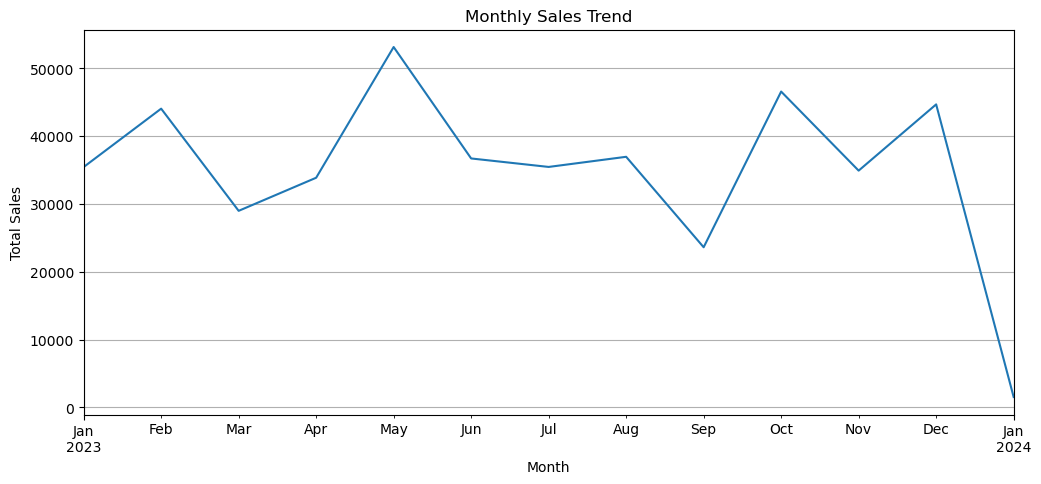

In [15]:
monthly_sales.plot(kind='line', figsize=(12, 5))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

## Quartely Sales Analyse

In [16]:
Quartely_sales = df.groupby(df['Date'].dt.to_period('W'))['Total Amount'].sum()

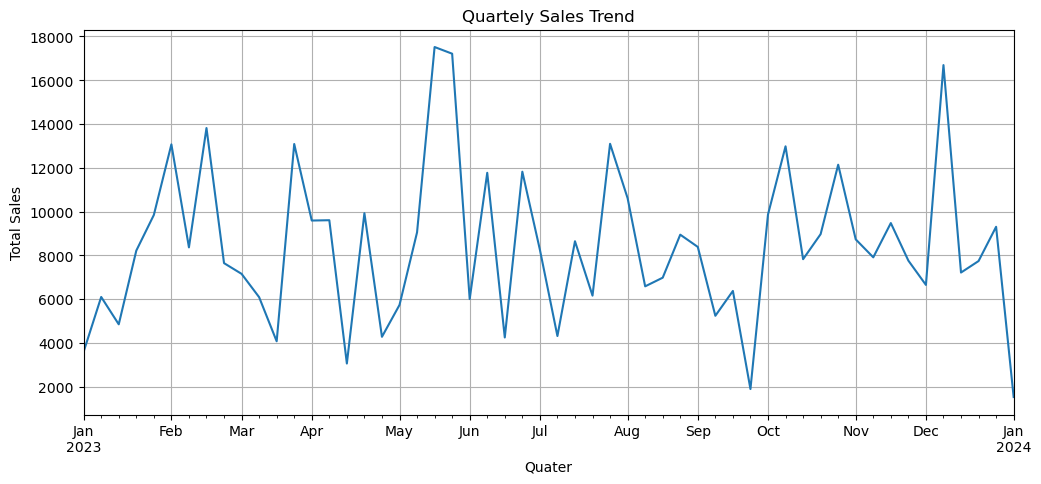

In [17]:
Quartely_sales.plot(kind='line', figsize=(12, 5))

plt.title('Quartely Sales Trend')
plt.xlabel('Quater')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

## Gender Count

In [18]:
gender_count = df['Gender'].value_counts()

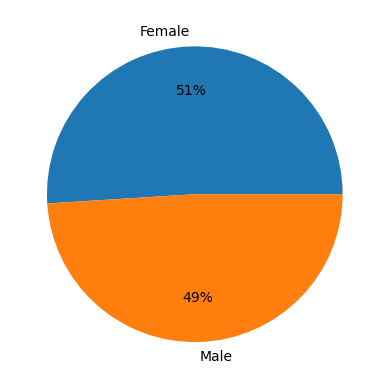

In [19]:
gender_counts = df['Gender'].value_counts()

gender_counts.plot(
    kind='pie',
    autopct='%1.0f%%',
    pctdistance=0.7
)

plt.ylabel('')
plt.show()

## Orders by Age Group Analyse

<Axes: xlabel='Age_Group'>

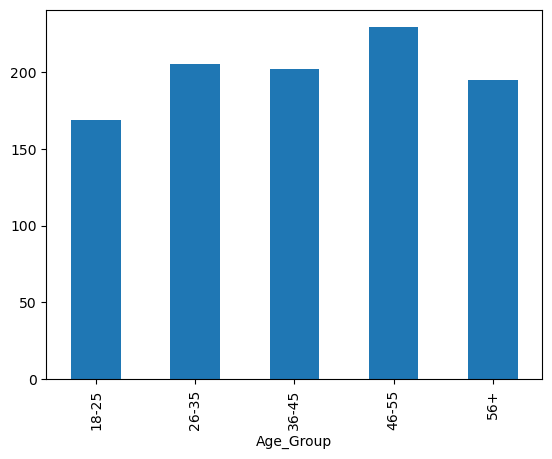

In [20]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)

age_counts = df['Age_Group'].value_counts().sort_index()
age_counts.plot(kind='bar')

## Revenue by Category

<Axes: title={'center': 'Revenue by Product Category'}, xlabel='Product Category'>

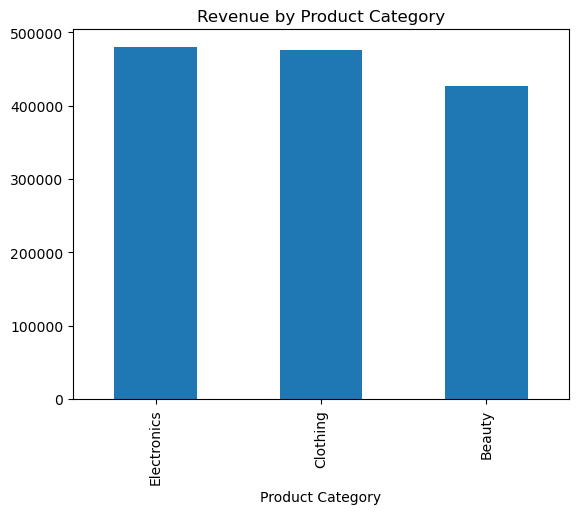

In [25]:
df['Revenue'] = df['Quantity'] * df['Total Amount']

category_revenue = (
    df.groupby('Product Category')['Revenue']
      .sum()
      .sort_values(ascending=False)
)

category_revenue.plot(
    kind='bar',
    title='Revenue by Product Category'
)

## Numeric Values Correlation

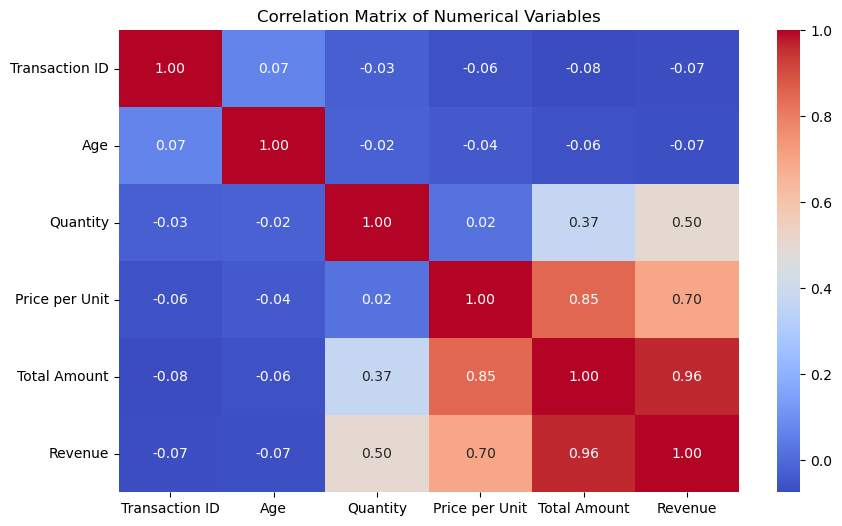

In [24]:
# Select numerical columns
numeric_df = df.select_dtypes(include='number')

# Calculate correlation
corr = numeric_df.corr()

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## Category wise Total Quantity

In [27]:
category_quantity = (
    df.groupby('Product Category')['Quantity']
      .sum()
      .sort_values(ascending=False)
)

print(category_quantity)

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


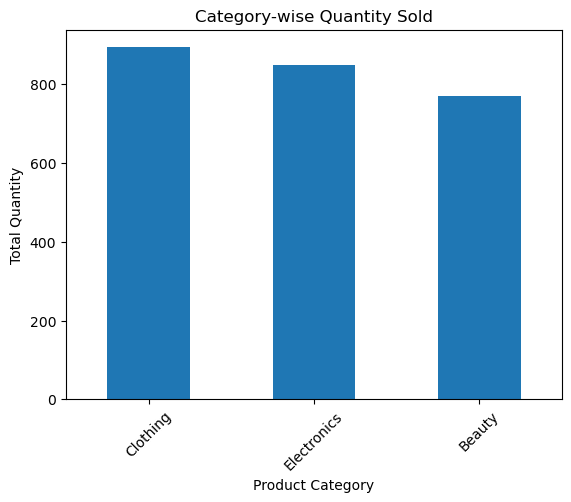

In [28]:
category_quantity.plot(
    kind='bar',
    title='Category-wise Quantity Sold',
    xlabel='Product Category',
    ylabel='Total Quantity'
)

plt.xticks(rotation=45)
plt.show()

# Business Insights

1. In which month Sales are high?

Ans - In the Month of May Sales are High

2. Which Product Category have given more revnue?

Ans - Electronics Category have given more revenue

3. Which Age Group taking more Orders?

Ans - 46 to 55 Age Group are taking more orders